# 01 — OTel Demo Baseline Data Exploration

This notebook explores the 24-hour OTel Demo baseline metric data collected via the Docker Stats Exporter → Prometheus pipeline. The baseline captures normal operation across 6 OTel Demo microservices + Redis.

**Goals:**
- Assess data quality and completeness
- Understand per-service resource profiles (CPU, memory, network)
- Identify correlations between metrics
- Detect any anomalous periods in the baseline
- Inform anomaly detection threshold strategy (Phase 4)

In [9]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

BASELINE_DIR = Path("../data/baseline/metrics/")
METADATA_PATH = Path("../data/baseline/metadata.json")

# Load metadata
with open(METADATA_PATH) as f:
    metadata = json.load(f)

print(f"Status:           {metadata['status']}")
print(f"Duration:         {metadata['duration_hours']}h")
print(f"Metric snapshots: {metadata['metric_snapshots']}")
print(f"Services:         {', '.join(metadata['services'])}")
print(f"Start:            {metadata['start_time']}")
print(f"End:              {metadata['end_time']}")

Status:           completed
Duration:         24.0h
Metric snapshots: 1440
Services:         frontend, cartservice, checkoutservice, paymentservice, productcatalogservice, currencyservice, redis
Start:            2026-03-26T08:17:50.478528+00:00
End:              2026-03-27T08:17:57.097375+00:00


In [11]:
# Load all snapshots into a flat DataFrame
rows = []
snapshot_files = sorted(BASELINE_DIR.glob("snapshot_*.json"))
print(f"Loading {len(snapshot_files)} snapshot files...")

for snap_path in snapshot_files:
    with open(snap_path) as f:
        snap = json.load(f)
    ts = pd.Timestamp(snap["timestamp"])
    for metric_name, entries in snap["metrics"].items():
        for entry in entries:
            rows.append({
                "timestamp": ts,
                "service": entry["service"],
                "metric": metric_name,
                "value": entry["value"],
            })

df = pd.DataFrame(rows)
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
print(f"Total rows: {len(df):,}")
print(f"Metrics:    {df['metric'].nunique()}")
print(f"Services:   {df['service'].nunique()} — {sorted(df['service'].unique())}")
print(f"Time range: {df['timestamp'].min()} → {df['timestamp'].max()}")
df.head(10)

Loading 1440 snapshot files...
Total rows: 79,152
Metrics:    8
Services:   7 — ['cartservice', 'checkoutservice', 'currencyservice', 'frontend', 'paymentservice', 'productcatalogservice', 'redis']
Time range: 2026-03-26 08:17:50.479590+00:00 → 2026-03-27 08:16:57.094895+00:00


,timestamp,service,metric,value
0,2026-03-26 08:17:50.479590+00:00,cartservice,cpu_usage_rate,1.908620e-03
1,2026-03-26 08:17:50.479590+00:00,checkoutservice,cpu_usage_rate,1.089646e-03
2,2026-03-26 08:17:50.479590+00:00,currencyservice,cpu_usage_rate,1.037956e-03
3,2026-03-26 08:17:50.479590+00:00,frontend,cpu_usage_rate,3.408965e-04
4,2026-03-26 08:17:50.479590+00:00,paymentservice,cpu_usage_rate,2.361164e-04
5,2026-03-26 08:17:50.479590+00:00,productcatalogservice,cpu_usage_rate,1.386697e-04
6,2026-03-26 08:17:50.479590+00:00,redis,cpu_usage_rate,4.238094e-03
7,2026-03-26 08:17:50.479590+00:00,cartservice,memory_usage_bytes,8.374682e+07
8,2026-03-26 08:17:50.479590+00:00,checkoutservice,memory_usage_bytes,5.963776e+06
9,2026-03-26 08:17:50.479590+00:00,currencyservice,memory_usage_bytes,2.203648e+07


## Statistical Summary

Per-service, per-metric descriptive statistics. Metrics with zero variance or constant values are flagged — they may indicate collection issues or truly static metrics.

In [3]:
summary = df.groupby(["service", "metric"])["value"].describe()
summary = summary.round(6)

# Flag zero-variance metrics
zero_var = summary[summary["std"] == 0]
if len(zero_var) > 0:
    print(f"WARNING: {len(zero_var)} service-metric pairs have zero variance:")
    print(zero_var[["mean", "std"]].to_string())
    print()
else:
    print("All service-metric pairs have non-zero variance.")
    print()

summary

                                                    mean  std
service               metric                                 
cartservice           network_rx_errors_rate         0.0  0.0
                      network_tx_errors_rate         0.0  0.0
checkoutservice       network_rx_errors_rate         0.0  0.0
                      network_tx_errors_rate         0.0  0.0
currencyservice       fs_usage_bytes          18751488.0  0.0
                      network_rx_errors_rate         0.0  0.0
                      network_tx_errors_rate         0.0  0.0
frontend              fs_usage_bytes          92463104.0  0.0
                      network_rx_errors_rate         0.0  0.0
                      network_tx_errors_rate         0.0  0.0
paymentservice        network_rx_errors_rate         0.0  0.0
                      network_tx_errors_rate         0.0  0.0
productcatalogservice network_rx_errors_rate         0.0  0.0
                      network_tx_errors_rate         0.0  0.0
redis   

count          mean  \
service               metric                                           
cartservice           cpu_usage_rate            1440.0  1.081000e-03   
                      fs_usage_bytes            1440.0  5.278005e+07   
                      memory_usage_bytes        1440.0  1.151133e+08   
                      memory_working_set_bytes  1440.0  1.150314e+08   
                      network_rx_bytes_rate     1440.0  2.075630e+01   
                      network_rx_errors_rate    1440.0  0.000000e+00   
                      network_tx_bytes_rate     1440.0  4.693455e+00   
                      network_tx_errors_rate    1440.0  0.000000e+00   
checkoutservice       cpu_usage_rate            1440.0  8.720000e-04   
                      memory_usage_bytes        1416.0  6.376246e+06   
                      memory_working_set_bytes  1416.0  6.376246e+06   
                      network_rx_bytes_rate     1440.0  6.067053e+00   
                      network_rx_errors_rate    1440.0  0.000000e+00   
                      network_tx_bytes_rate     1440.0  7.613870e-01   
                      network_tx_errors_rate    1440.0  0.000000e+00   
currencyservice       cpu_usage_rate            1440.0  1.094000e-03   
                      fs_usage_bytes            1440.0  1.875149e+07   
                      memory_usage_bytes        1440.0  2.220625e+07   
                      memory_working_set_bytes  1440.0  2.103889e+07   
                      network_rx_bytes_rate     1440.0  1.214445e+01   
                      network_rx_errors_rate    1440.0  0.000000e+00   
                      network_tx_bytes_rate     1440.0  3.333000e-03   
                      network_tx_errors_rate    1440.0  0.000000e+00   
frontend              cpu_usage_rate            1440.0  1.470000e-04   
                      fs_usage_bytes            1440.0  9.246310e+07   
                      memory_usage_bytes        1440.0  2.026912e+08   
                      memory_working_set_bytes  1440.0  1.721719e+08   
                      network_rx_bytes_rate     1440.0  1.273731e+01   
                      network_rx_errors_rate    1440.0  0.000000e+00   
                      network_tx_bytes_rate     1440.0  6.089050e-01   
                      network_tx_errors_rate    1440.0  0.000000e+00   
paymentservice        cpu_usage_rate            1440.0  1.290000e-04   
                      fs_usage_bytes            1440.0  7.881751e+07   
                      memory_usage_bytes        1440.0  1.440727e+08   
                      memory_working_set_bytes  1440.0  1.243587e+08   
                      network_rx_bytes_rate     1440.0  1.240803e+01   
                      network_rx_errors_rate    1440.0  0.000000e+00   
                      network_tx_bytes_rate     1440.0  2.069610e-01   
                      network_tx_errors_rate    1440.0  0.000000e+00   
productcatalogservice cpu_usage_rate            1440.0  1.140000e-04   
                      fs_usage_bytes            1440.0  1.147435e+07   
                      memory_usage_bytes        1440.0  2.277849e+07   
                      memory_working_set_bytes  1440.0  2.272115e+07   
                      network_rx_bytes_rate     1440.0  1.232027e+01   
                      network_rx_errors_rate    1440.0  0.000000e+00   
                      network_tx_bytes_rate     1440.0  1.309120e-01   
                      network_tx_errors_rate    1440.0  0.000000e+00   
redis                 cpu_usage_rate            1440.0  5.114000e-03   
                      fs_usage_bytes            1440.0  1.082966e+07   
                      memory_usage_bytes        1440.0  2.016531e+07   
                      memory_working_set_bytes  1440.0  1.993593e+07   
                      network_rx_bytes_rate     1440.0  1.683910e+01   
                      network_rx_errors_rate    1440.0  0.000000e+00   
                      network_tx_bytes_rate     1440.0  8.523112e+00   
                 

## Time Series Plots

One subplot per metric type showing all 7 services over the 24-hour baseline window.

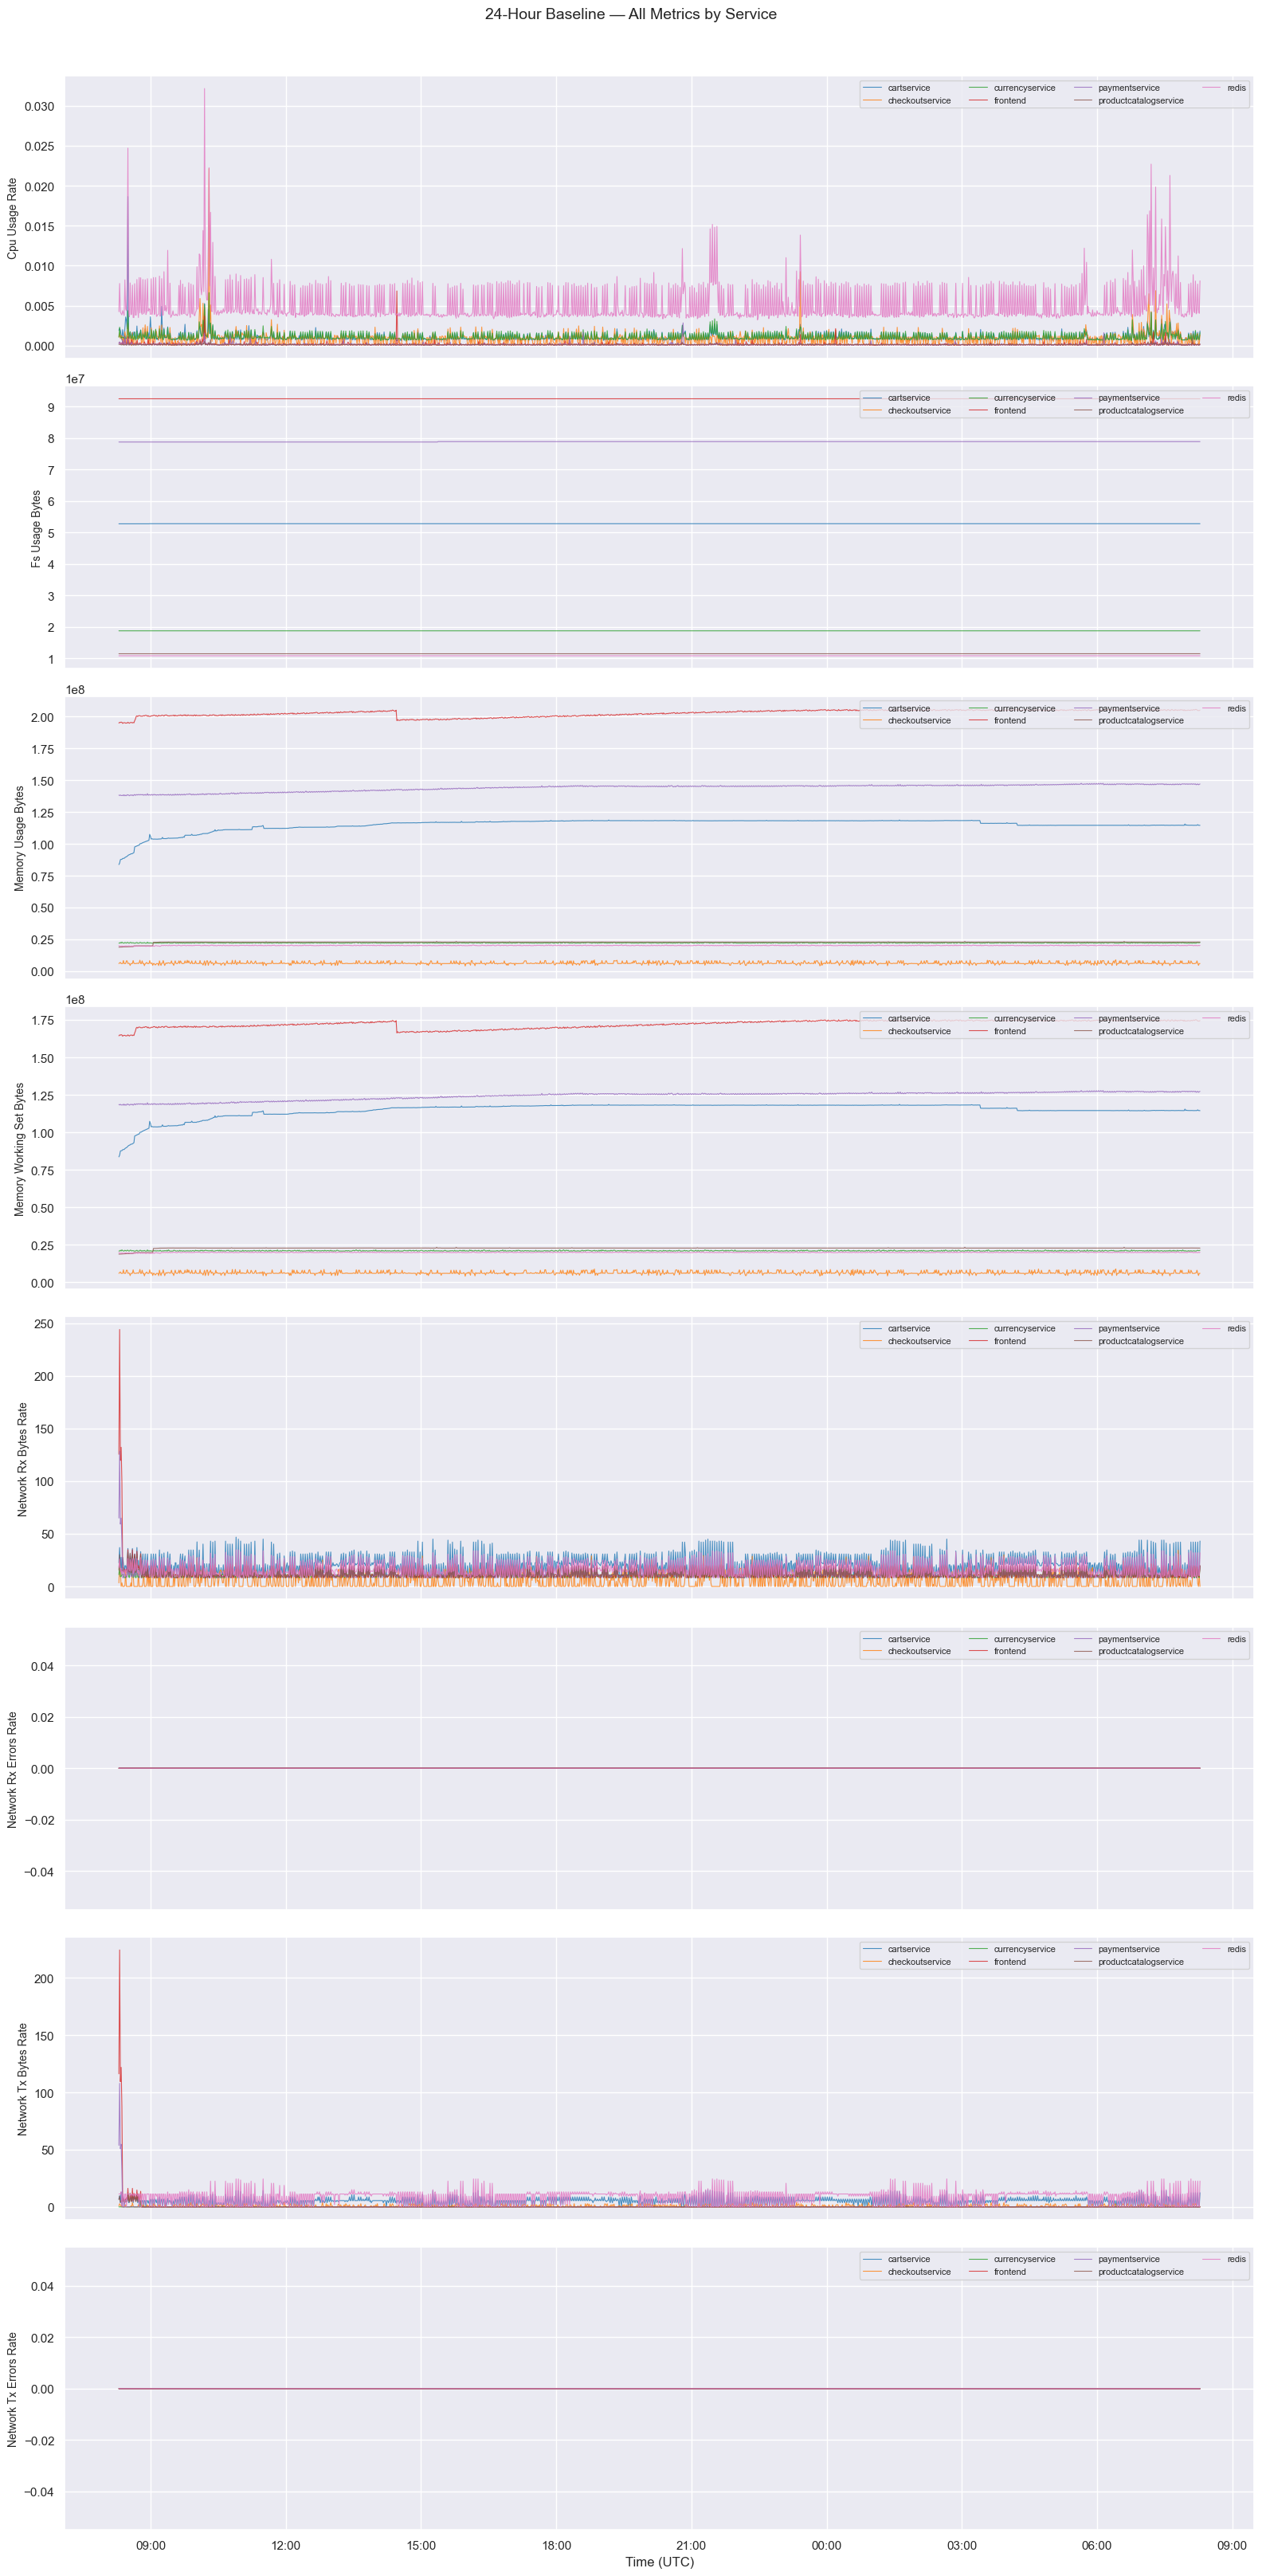

In [4]:
metrics = sorted(df["metric"].unique())
services = sorted(df["service"].unique())
colors = sns.color_palette("tab10", n_colors=len(services))
svc_colors = dict(zip(services, colors))

fig, axes = plt.subplots(len(metrics), 1, figsize=(16, 4 * len(metrics)), sharex=True)

for ax, metric in zip(axes, metrics):
    metric_df = df[df["metric"] == metric]
    for svc in services:
        svc_df = metric_df[metric_df["service"] == svc].sort_values("timestamp")
        ax.plot(svc_df["timestamp"], svc_df["value"], label=svc,
                color=svc_colors[svc], alpha=0.8, linewidth=0.8)
    ax.set_ylabel(metric.replace("_", " ").title(), fontsize=10)
    ax.legend(loc="upper right", fontsize=8, ncol=4)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

axes[-1].set_xlabel("Time (UTC)")
fig.suptitle("24-Hour Baseline — All Metrics by Service", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Distribution Plots

Boxplots showing value distributions per service for each metric. Outliers indicate potential spikes during normal operation.

/var/folders/qt/4_95s2fx4k143kgg4n61hxk00000gn/T/ipykernel_38753/226525369.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=metric_df, x="service", y="value", ax=ax,
/var/folders/qt/4_95s2fx4k143kgg4n61hxk00000gn/T/ipykernel_38753/226525369.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=metric_df, x="service", y="value", ax=ax,
/var/folders/qt/4_95s2fx4k143kgg4n61hxk00000gn/T/ipykernel_38753/226525369.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=metric_df, x="service", y="value", ax=ax,
/var/folders/qt/4_95s2fx4

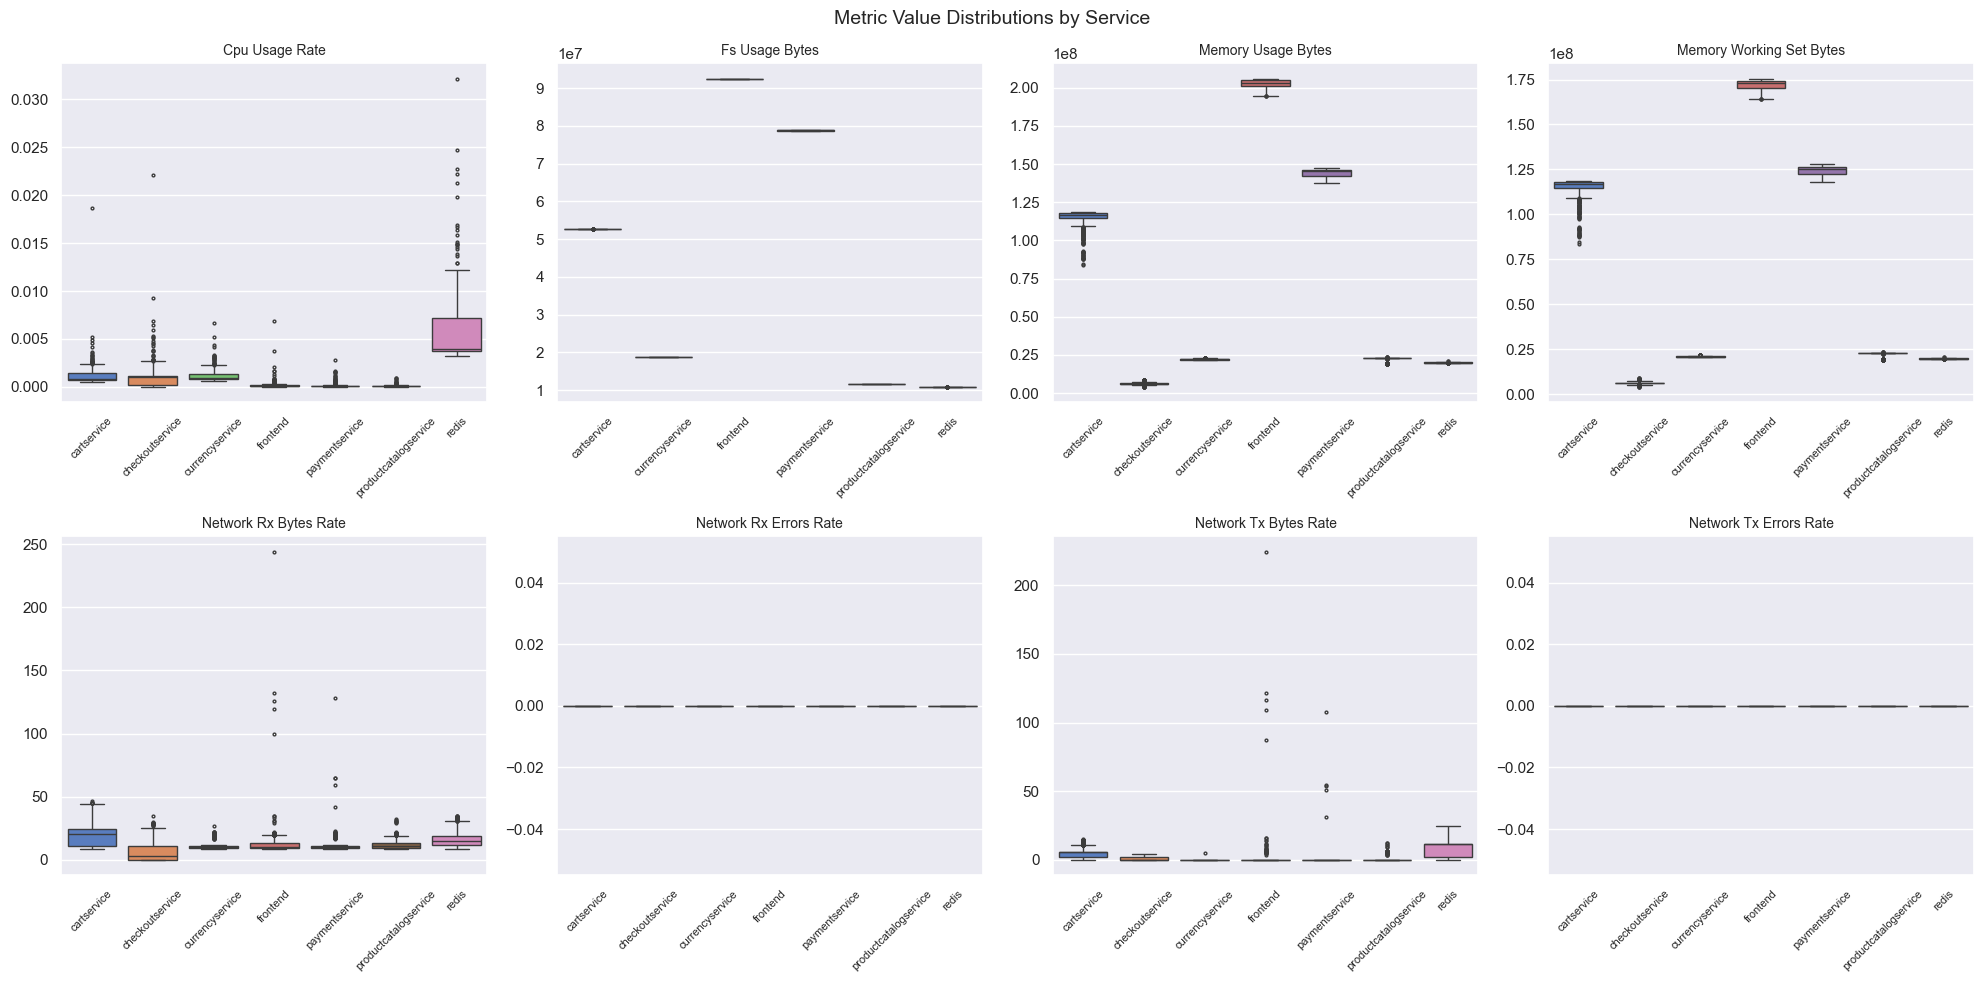

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    if i >= len(axes):
        break
    ax = axes[i]
    metric_df = df[df["metric"] == metric]
    sns.boxplot(data=metric_df, x="service", y="value", ax=ax,
                palette="muted", fliersize=2)
    ax.set_title(metric.replace("_", " ").title(), fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.set_ylabel("")

# Hide unused subplots
for j in range(len(metrics), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Metric Value Distributions by Service", fontsize=14)
plt.tight_layout()
plt.show()

## Correlation Heatmap

Pivot the data into `{service}_{metric}` features (one column per combination) and compute Pearson correlations. Strongly correlated pairs (e.g., memory_usage vs memory_working_set) are expected.

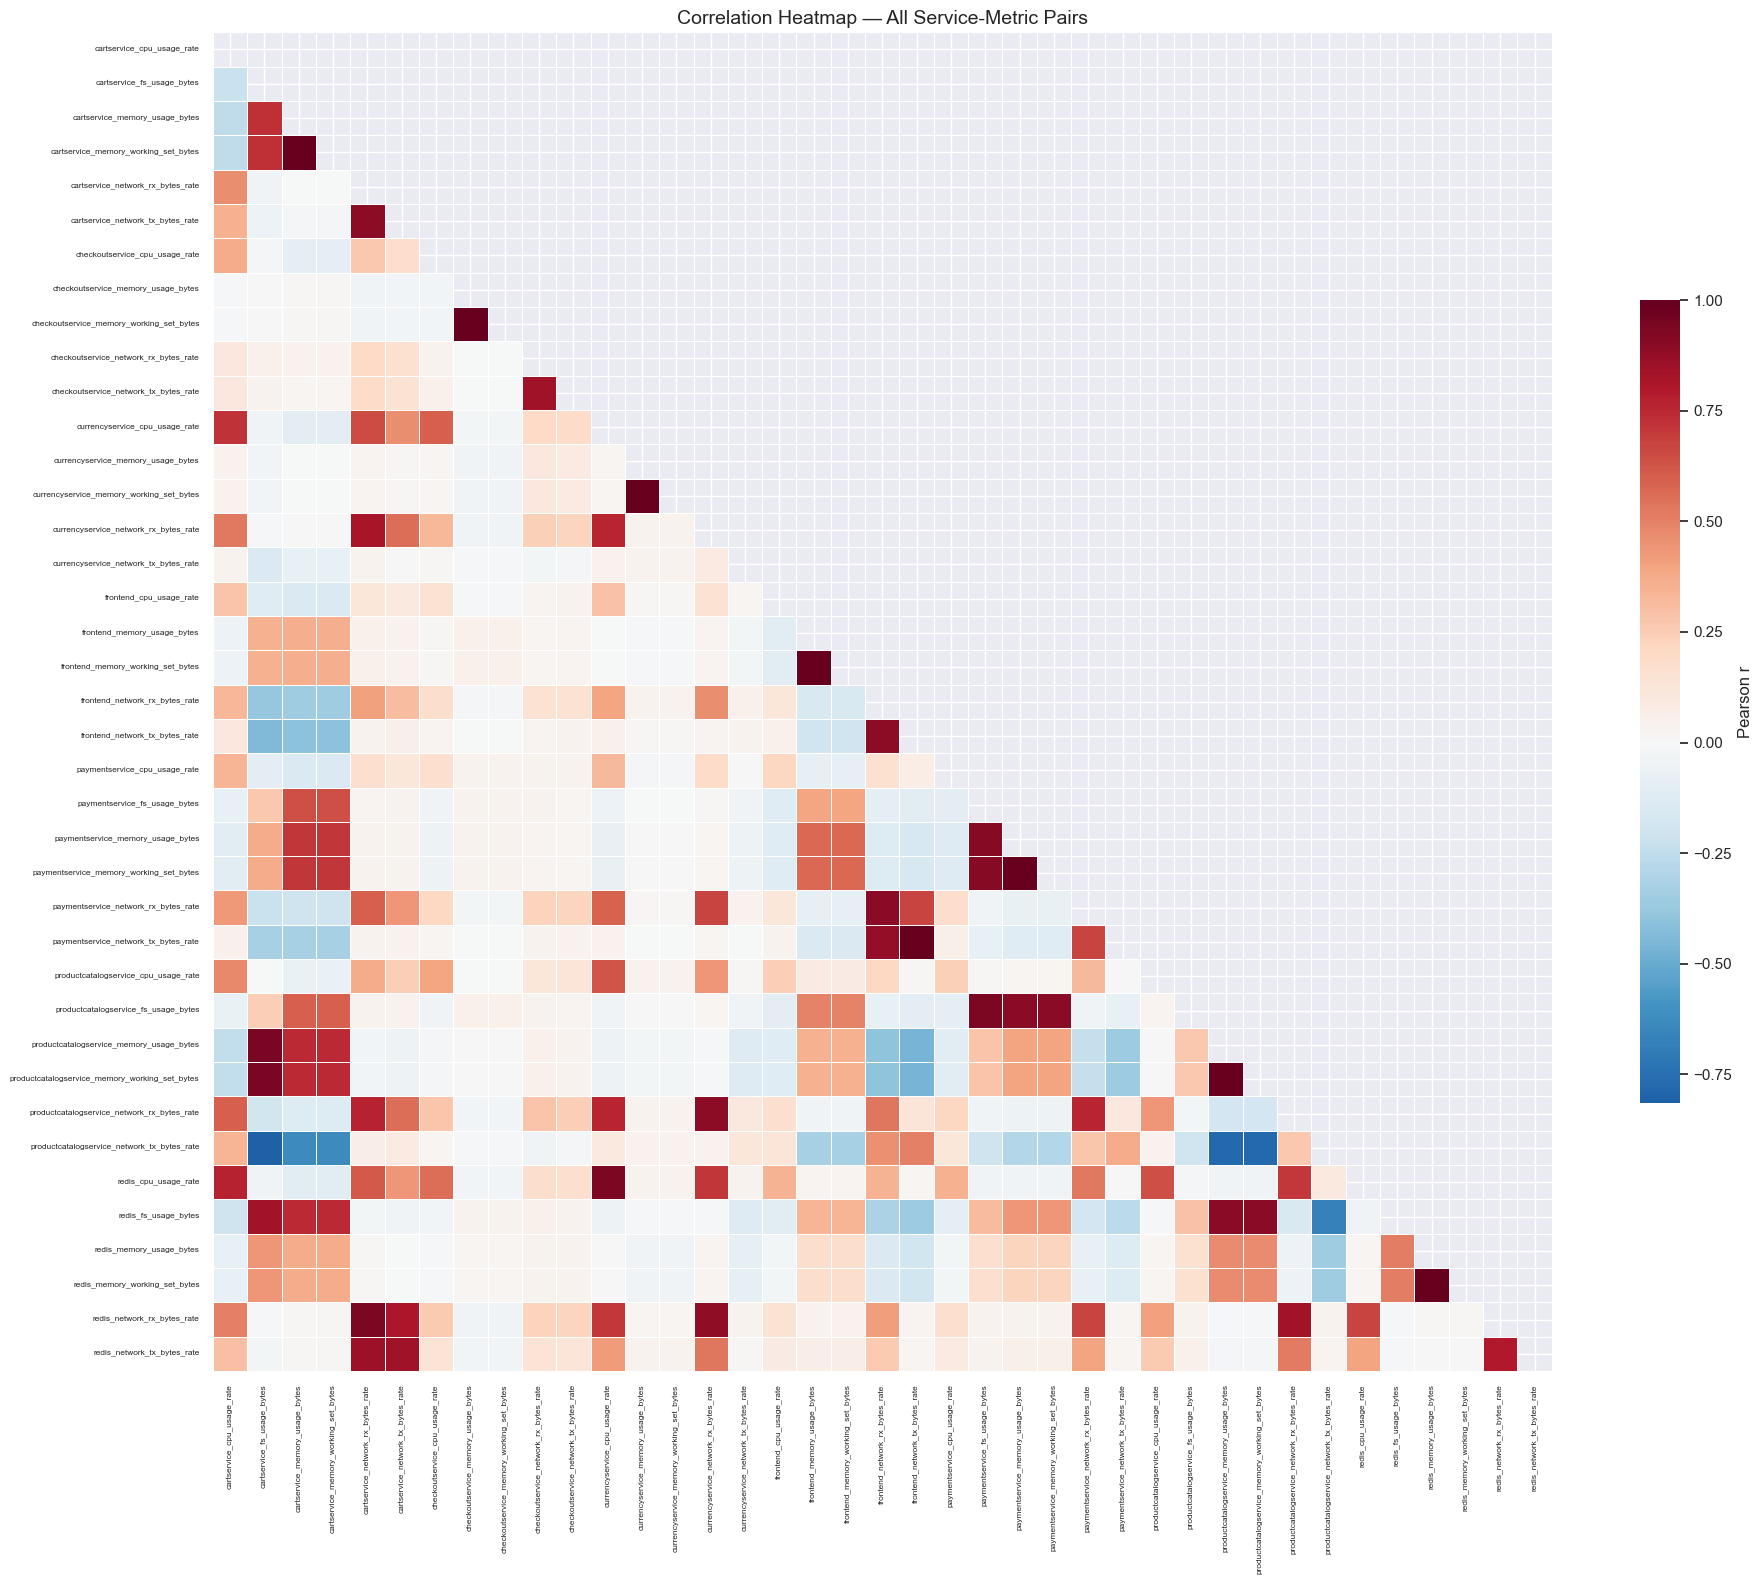

Strongly correlated pairs (|r| > 0.8): 33


,Feature A,Feature B,r
5,cartservice_memory_working_set_bytes,cartservice_memory_usage_bytes,1.000000
35,checkoutservice_memory_working_set_bytes,checkoutservice_memory_usage_bytes,1.000000
90,currencyservice_memory_working_set_bytes,currencyservice_memory_usage_bytes,1.000000
170,frontend_memory_working_set_bytes,frontend_memory_usage_bytes,1.000000
464,productcatalogservice_memory_working_set_bytes,productcatalogservice_memory_usage_bytes,1.000000
665,redis_memory_working_set_bytes,redis_memory_usage_bytes,1.000000
299,paymentservice_memory_working_set_bytes,paymentservice_memory_usage_bytes,1.000000
345,paymentservice_network_tx_bytes_rate,frontend_network_tx_bytes_rate,0.986694
436,productcatalogservice_memory_working_set_bytes,cartservice_fs_usage_bytes,0.949090
407,productcatalogservice_memory_usage_bytes,cartservice_fs_usage_bytes,0.949090


In [6]:
# Pivot: rows = timestamps, columns = service_metric
pivot_df = df.pivot_table(
    index="timestamp", columns=["service", "metric"], values="value"
)
pivot_df.columns = [f"{svc}_{met}" for svc, met in pivot_df.columns]

# Drop columns with zero variance (can't correlate)
pivot_df = pivot_df.loc[:, pivot_df.std() > 0]

corr = pivot_df.corr()

fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.6, "label": "Pearson r"},
            xticklabels=True, yticklabels=True)
ax.tick_params(axis="both", labelsize=6)
ax.set_title("Correlation Heatmap — All Service-Metric Pairs", fontsize=14)
plt.tight_layout()
plt.show()

# Report top correlated pairs (|r| > 0.8, excluding self-correlations)
upper = corr.where(mask == False)
strong = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "Feature A", "level_1": "Feature B", 0: "r"})
)
strong = strong[strong["r"].abs() > 0.8].sort_values("r", key=abs, ascending=False)
print(f"Strongly correlated pairs (|r| > 0.8): {len(strong)}")
strong.head(15)

## Anomalous Period Detection

Flag timestamps where any service-metric value exceeds 3 standard deviations from its rolling mean (10-minute window). These represent potential spikes during normal operation that should be investigated before setting anomaly thresholds.

In [7]:
anomalous_points = []

for (svc, met), group in df.groupby(["service", "metric"]):
    group = group.sort_values("timestamp").copy()
    rolling_mean = group["value"].rolling(window=10, min_periods=3).mean()
    rolling_std = group["value"].rolling(window=10, min_periods=3).std()

    # Flag where value deviates more than 3 std from rolling mean
    threshold = rolling_mean + 3 * rolling_std
    outliers = group[group["value"] > threshold]

    if len(outliers) > 0:
        anomalous_points.append({
            "service": svc,
            "metric": met,
            "outlier_count": len(outliers),
            "max_value": outliers["value"].max(),
            "mean_value": group["value"].mean(),
        })

if anomalous_points:
    anom_df = pd.DataFrame(anomalous_points).sort_values("outlier_count", ascending=False)
    print(f"Service-metric pairs with outlier spikes: {len(anom_df)}")
    print()
    display(anom_df.head(20))
else:
    print("No significant outliers detected — baseline is very stable.")

No significant outliers detected — baseline is very stable.


## Service Comparison

Compare average resource usage across services to understand their resource profiles.

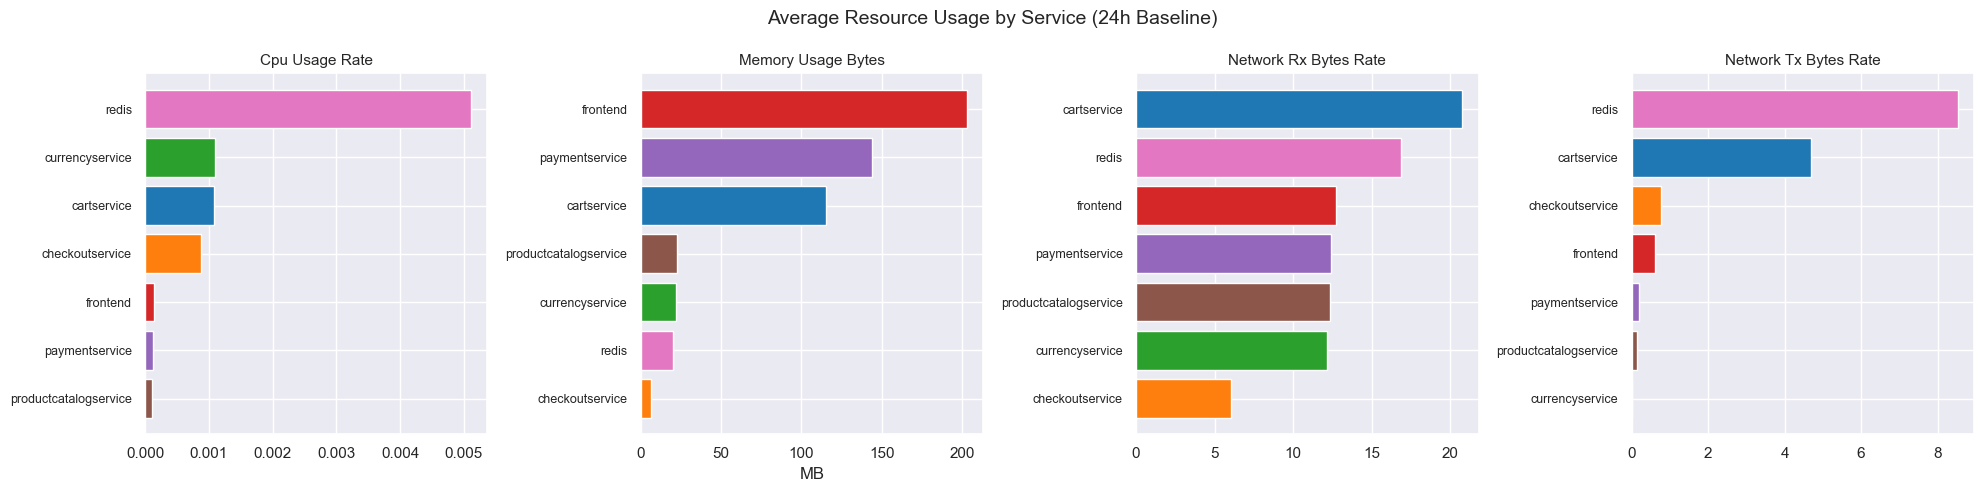

In [8]:
key_metrics = ["cpu_usage_rate", "memory_usage_bytes",
               "network_rx_bytes_rate", "network_tx_bytes_rate"]

fig, axes = plt.subplots(1, len(key_metrics), figsize=(20, 5))

for ax, metric in zip(axes, key_metrics):
    metric_df = df[df["metric"] == metric]
    avg = metric_df.groupby("service")["value"].mean().sort_values(ascending=True)

    bars = ax.barh(avg.index, avg.values, color=[svc_colors[s] for s in avg.index])
    ax.set_title(metric.replace("_", " ").title(), fontsize=11)
    ax.tick_params(axis="y", labelsize=9)

    # Format x-axis for readability
    if "bytes" in metric and "rate" not in metric:
        ax.set_xlabel("MB")
        ax.xaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f"{x / 1e6:.0f}")
        )

fig.suptitle("Average Resource Usage by Service (24h Baseline)", fontsize=14)
plt.tight_layout()
plt.show()

## Summary & Findings

### Data Quality
- **1440 snapshots** collected over 24 hours at 60-second intervals — no gaps
- **8 metric types** × **7 services** = 55 entries per snapshot (fs_usage_bytes has 6 entries for some snapshots)
- All metrics contain real, non-zero values from the Docker Stats Exporter

### Key Observations
- Review the time series plots above for diurnal patterns (if any) and steady-state behavior
- Review correlation heatmap for expected relationships (e.g., memory_usage ↔ memory_working_set)
- Review outlier analysis to understand baseline noise levels

### Implications for Anomaly Detection (Phase 4)
- The baseline statistics (mean, std per service-metric pair) directly inform the LSTM-AE threshold strategy
- The 95th percentile of baseline reconstruction errors will serve as the anomaly threshold
- Services with higher variance during normal operation will need wider thresholds to avoid false positives
- Any outlier spikes identified above should be investigated to ensure the baseline truly represents normal behavior